# Window Shopping \U0001FA9F
### How much history should an estimate use? It depends what you are estimating.

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Fragile](https://img.shields.io/badge/Usefulness-Fragile-dab617?style=flat-square)

Five years, because that is what the terminal shows. Or everything, because more data must be
better. Nobody ever tests it. This notebook does: three things a portfolio needs — a beta, an
expected return, a covariance matrix — estimated from six different windows and then judged by
the year that came next.

> \U0001F4D3 **This is the plain-language layer.** The paired-error tests and the
> observations-per-parameter arithmetic are in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Estimating... | Best window | Why |
|---|---|---|
| **A beta** | medium, then shrink | Betas move, but slowly; a short window is mostly noise and a long one is mostly stale. |
| **An expected return** | as much as possible — and even then, don't | Means are so imprecise that the cross-sectional average beats a sector's own history. |
| **A covariance matrix** | long enough to have rows per parameter | Below that line the optimiser stops estimating risk and starts amplifying error. |

## 1 · The claim

> *"Use five years of monthly data."* — every risk textbook, and every terminal's default.
>
> *"No, use everything you have; more data is more information."* — every statistician who has
> not thought about structural change.

Both are answers to a question nobody states precisely: *more information about what?*

## 2 · So what?

The window choice is invisible and consequential. It sets your hedge ratio, your risk limits
and — through the covariance matrix — the entire shape of an optimised portfolio. And unlike a
strategy, it is never backtested: it is inherited.

In [2]:
from window_choice import data, strategy as st

px = data.load_prices()
rets = st.to_returns(px)
sectors = tuple(s for s in data.SECTORS if rets[s].notna().sum() > 500)
print(f"as-of {data.AS_OF} | {len(sectors)} sectors | "
      f"{px.index[0].date()} -> {px.index[-1].date()}")
print("inceptions:", ", ".join(f"{s}:{px[s].dropna().index[0].year}" for s in data.SECTORS))

as-of 2026-06-30 | 11 sectors | 1993-01-29 -> 2026-06-30
inceptions: XLB:1998, XLC:2018, XLE:1998, XLF:1998, XLI:1998, XLK:2000, XLP:1998, XLRE:2015, XLU:1998, XLV:2000, XLY:1998


## 3 · How would we even know?

Stand at the end of each year. Estimate the thing from the last 1, 2, 3, 5, 10 years, and from
everything you have. Then wait a year and see which estimate was closest. Repeat for every
year in the sample.

## 4 · The teardown

### 4.1 Beta

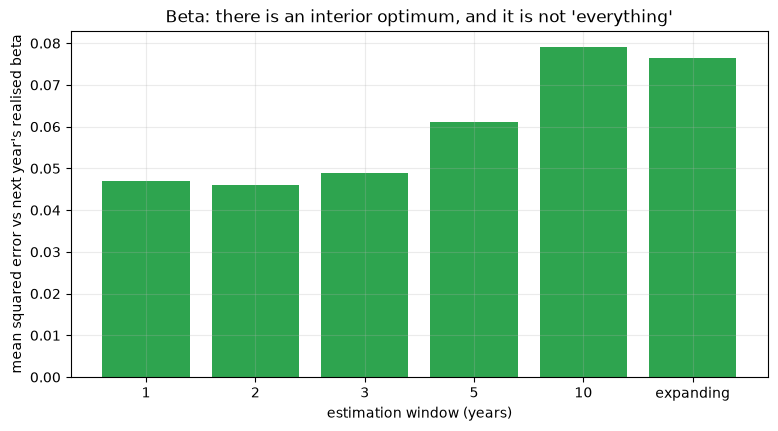

,mse,bias,mae,n
window,,,,
1,0.0470,0.0124,0.1506,256
2,0.0460,0.0170,0.1536,256
3,0.0488,0.0181,0.1652,256
5,0.0612,0.0166,0.1856,256
10,0.0791,0.0022,0.2088,256
expanding,0.0765,-0.0269,0.2056,256


In [3]:
bexp = st.beta_experiment(rets, sectors, data.MARKET)
bsc = st.score(bexp)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar([str(w) for w in bsc.index], bsc["mse"], color="#2ea44f")
ax.set_ylabel("mean squared error vs next year's realised beta")
ax.set_xlabel("estimation window (years)")
ax.set_title("Beta: there is an interior optimum, and it is not 'everything'")
plt.show()
bsc.round(5)

### 4.2 The mean return, and a very humbling benchmark

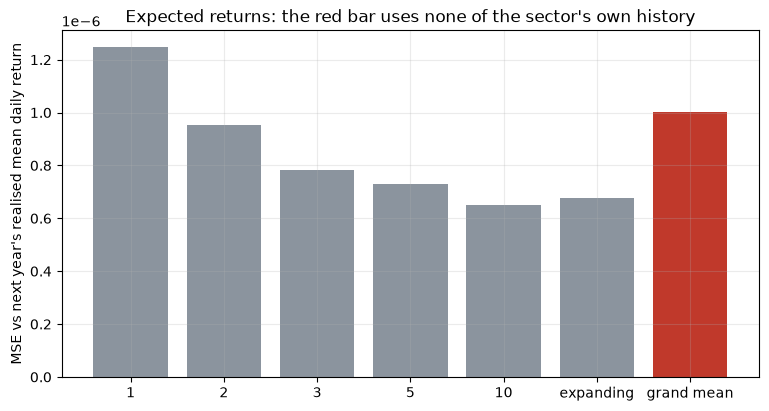

,mse,bias,mae,n
window,,,,
1,0.0000,-0.0000,0.0008,256
2,0.0000,-0.0000,0.0008,256
3,0.0000,-0.0000,0.0007,256
5,0.0000,-0.0000,0.0007,256
10,0.0000,-0.0001,0.0006,256
expanding,0.0000,-0.0001,0.0006,256
grand mean,0.0000,-0.0000,0.0007,270


In [4]:
mexp = st.mean_experiment(rets, sectors)
gm = st.grand_mean_benchmark(rets, sectors)
msc = st.score(pd.concat([mexp, gm], ignore_index=True))
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#c0392b" if w == "grand mean" else "#8b949e" for w in msc.index]
ax.bar([str(w) for w in msc.index], msc["mse"], color=colors)
ax.set_ylabel("MSE vs next year's realised mean daily return")
ax.set_title("Expected returns: the red bar uses none of the sector's own history")
plt.show()
msc.round(8)

> \U0001F52C **For the quants.** Merton (1980): the standard error of a mean depends on the
> calendar span, not the number of observations, so sampling daily instead of monthly buys you
> nothing at all on this parameter. Twenty-eight years of data still leaves the sector means
> statistically indistinguishable from one another.

### 4.3 The covariance matrix, judged by the portfolio it builds

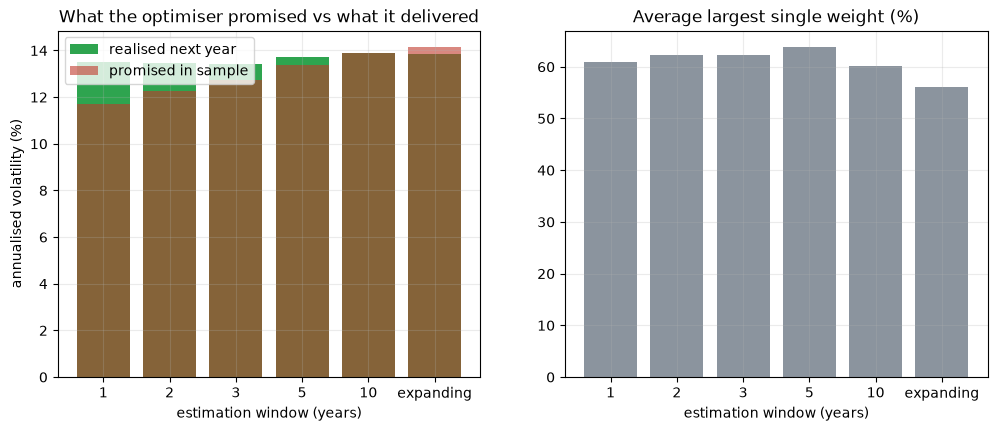

,realised,predicted,max_w
window,,,
1,0.1349,0.1169,0.6099
2,0.1345,0.1226,0.6228
3,0.1344,0.1272,0.6234
5,0.1371,0.1339,0.6382
10,0.1388,0.1388,0.6023
expanding,0.1384,0.1415,0.5607


In [5]:
cexp = st.covariance_experiment(rets, sectors)
csc = cexp.groupby("window").agg(realised=("realised_vol", "mean"),
                                 predicted=("predicted_vol", "mean"),
                                 max_w=("max_weight", "mean"))
order = [w for w in list(st.WINDOWS_YEARS) + [st.EXPANDING] if w in csc.index]
csc = csc.loc[order]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar([str(w) for w in csc.index], csc["realised"] * 100, color="#2ea44f",
            label="realised next year")
axes[0].bar([str(w) for w in csc.index], csc["predicted"] * 100, color="#c0392b",
            alpha=0.6, label="promised in sample")
axes[0].set_ylabel("annualised volatility (%)"); axes[0].legend()
axes[0].set_title("What the optimiser promised vs what it delivered")
axes[1].bar([str(w) for w in csc.index], csc["max_w"] * 100, color="#8b949e")
axes[1].set_title("Average largest single weight (%)")
for a in axes:
    a.set_xlabel("estimation window (years)")
plt.show()
csc.round(4)

The short-window optimiser is confident and wrong: it promises the lowest volatility and
delivers the highest, while concentrating the portfolio into whichever sector happened to look
quietest last year.

## 5 · The verdict

**Signal: Real.** Yes, and by more than habit would suggest. Across estimation windows the MSE spread is **72%** for beta, **92%** for the mean return and **3%** for the volatility of the minimum-variance portfolio; the strongest pairwise Diebold-Mariano across the three experiments is **+3.45**. The three quantities do not agree with each other: beta wants **2**, the mean wants **10**, the covariance matrix wants **3**.

**Usefulness: Fragile.** There is no single default. The mean is the extreme case: even the *best* window of a sector's own history is beaten by the **grand mean across all sectors** (MSE ratio 1.54), which is the empirical way of saying individual expected returns are not estimable from price history at all. Beta is estimable and mildly non-stationary — Blume shrinkage cuts its MSE by a further **-10%**. The covariance matrix is the one place where a short window is actively dangerous: at 11 assets, a one-year window has about 42.0 observations per estimated parameter.

## 6 · What should you actually do?

- **Beta:** a few years, then shrink toward 1 (Blume). The shrinkage is worth more than the
  window choice.
- **Expected returns:** do not estimate them per asset from price history. Use a cross-sectional
  anchor, or a model, or an assumption you are willing to defend.
- **Covariance:** count your parameters before you choose your window; if rows-per-parameter
  is in single digits, shrink the matrix (study 975) or reduce the cross-section.

## 7 · Going further \U0001F6AA

- **Structural-break tests** (Bai-Perron) to choose the window *endogenously* instead of by
  grid search.
- **Exponential weighting** instead of a hard cut-off: a half-life is a smoother version of the
  same trade-off.
- **A wider cross-section.** Eleven sectors is a friendly matrix; at 500 stocks every effect
  here becomes dramatic.